In [2]:
from collections import defaultdict
import pandas as pd
import os
import csv
from itertools import combinations
import kagglehub

dir_path = kagglehub.dataset_download("andrewmvd/spotify-playlists")
path = os.path.join(dir_path, "spotify_dataset.csv")

playlists = defaultdict(list)
transactions = []

# read the file in chunks
for chunk in pd.read_csv(path, chunksize=50000, on_bad_lines="skip"):

    # titles of csv columns were imported with extra ' 's
    # drop rows that have any null values in the row
    chunk.columns = [c.replace('"', '').strip() for c in chunk.columns]
    chunk = chunk.dropna(subset=["user_id", "playlistname", "trackname", "artistname"])

    # make the key unique with (userid, playlist) in case a playlist name is the same
    # make the value unique in case there's a song with the same title
    for row in chunk.itertuples(index=False):
        key = (row.user_id, row.playlistname)
        song = f"{row.trackname} - {row.artistname}"
        playlists[key].append(song)

# create a transactions array like the one we did in class
transactions = [frozenset(songs) for songs in playlists.values()]
print(len(transactions))

231560


In [3]:
# get a sense of how different support thresholds prune our items so we can pick the right one
from collections import Counter

# gives a count of how many transactions each song appears in aka support count
song_counts = Counter(item for t in transactions for item in t)

num_trans= len(transactions)  # 231560

# experimenting with some thresholds

print(f"Total number of items (non-duplicates) in across all transactions: {len(song_counts)}")

for min_support in [0.002, 0.001, 0.005, 0.01, 0.02]:
    passes_threshold = sum(1 for c in song_counts.values() if c / num_trans >= min_support)
    print(f"min_support={min_support:.4f} → {passes_threshold:,} items pass this threshold")


Total number of items (non-duplicates) in across all transactions: 2789644
min_support=0.0020 → 1,107 items pass this threshold
min_support=0.0010 → 3,747 items pass this threshold
min_support=0.0050 → 102 items pass this threshold
min_support=0.0100 → 3 items pass this threshold
min_support=0.0200 → 0 items pass this threshold


Looking at the output above we can see that choosing a support of 0.005, 0.010, or 0.020 prunes items in the transactions quite aggressively and doesn't leave many items to generate rules from. Additionally, we want to also avoid choosing a min_support that is too low which can cause Apriori to struggle with huge candidate sets. We see quite a large jump between 0.0005 and 0.001, so we chose to use 0.001 as our minimum threshold for this project.

Additionally, with min_support = 0.001 we see that only 3747 items pass the threshold which is a very small fraction out of the 2789644 items. Thus, we can deduce that there may be a lot of rare songs and have decided to clean and process the transactions arrar accordingly (also helps with Apriori algorithm execution a lot). To try and keep as many frequent itemsets as possible (since we already cut data down to help Apriori execute), we experimented with low minimum support values.



In [4]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# filtering to pre-prune before Apriori (otherwise will take very long)

# remove playlists with only one song (can't generate rules from)
# grab the top 200 songs using support counts from song_counts from before
top_100 = {song for song, count in song_counts.most_common(100)}
print("got top songs!")

# keep only the top 200 in the filtered_transactions that we'll use for Apriori
filtered_transactions = [[s for s in t if s in top_100] for t in transactions]
print("filtered based off top songs")

filtered_transactions = [t for t in filtered_transactions if len(t) >= 2] # removes playlists with only one song 
print(len(filtered_transactions))

te = TransactionEncoder()
df = pd.DataFrame(te.fit_transform(filtered_transactions), columns=te.columns_)
freq_items = apriori(df, min_support=0.0005, use_colnames=True, verbose=1, max_len=3)
freq_items['length'] = freq_items['itemsets'].apply(len)

print(f"Frequent itemsets found: {len(freq_items):,}")

got top songs!
filtered based off top songs
23339
Processing 485100 combinations | Sampling itemset size 3
Frequent itemsets found: 139,985


In [5]:
rules = association_rules(freq_items, metric="confidence", min_threshold=0.70)
rules = rules.sort_values('lift', ascending=False)
print(f"Rules found: {len(rules):,}")
print(rules[['antecedents','consequents','support','confidence','lift']].head(10))

Rules found: 296
                                           antecedents  \
201  frozenset({Instant Crush - Daft Punk, Get Luck...   
4    frozenset({A Sky Full of Stars - Coldplay, Fix...   
8    frozenset({Yellow - Coldplay, A Sky Full of St...   
202  frozenset({Lose Yourself to Dance - Daft Punk,...   
74   frozenset({Smells Like Teen Spirit - Nirvana, ...   
269  frozenset({The Scientist - Coldplay, Summer - ...   
23   frozenset({Smells Like Teen Spirit - Nirvana, ...   
197  frozenset({Yellow - Coldplay, Fix You - Coldpl...   
294  frozenset({Yellow - Coldplay, Viva La Vida - C...   
295  frozenset({The Scientist - Coldplay, Viva La V...   

                                         consequents   support  confidence  \
201  frozenset({Lose Yourself to Dance - Daft Punk})  0.028450    0.915862   
4                      frozenset({Magic - Coldplay})  0.005184    0.724551   
8                      frozenset({Magic - Coldplay})  0.004028    0.717557   
202           frozenset({Instant

In [6]:
# we have our strong rules above. now we want to build how we recommend using that.
# first filter out metrics above a certain threshold
# for the input playlist, if it has the antencdent we recommmend the consequent if not already contained
def recommend_songs(input_playlist, rules, top_n=50):
    filtered_rules = rules[(rules['support'] >= 0.005) & (rules['lift'] >= 2.0)].copy()
    recommendations = []
    

    for _, row in filtered_rules.iterrows():
        antecedent = set(row['antecedents']) # songs we have
        consequent = set(row['consequents']) # songs we would recommend

        # if the playlist contains all the songs we have, recommend if not already in the playlist
        if antecedent.issubset(input_playlist):
            for song in consequent:
                if song not in input_playlist:
                    recommendations.append((song, antecedent, consequent, row['confidence'], row['lift']))

    # sort by lift (or confidence)
    recommendations.sort(key=lambda x: x[4], reverse=True)  # lift
    return recommendations[:top_n]

input_playlist = {
    "Yellow - Coldplay",
    "Fix You - Coldplay",
    "Viva La Vida - Coldplay"
}

recommended_songs = recommend_songs(input_playlist, rules)

print(f"=== Final Recommended Songs For an Example Playlist ===")
print(f"{'title':30} {'antecedent':50} {'consequent':29} {'confidence':20} {'lift'}")
for song, antecedent, consequent, conf, lift in recommended_songs:

    print(f"{song:30} {str(antecedent):30} {str(consequent):30} {conf:15.2f} {lift:15.2f}")



=== Final Recommended Songs For an Example Playlist ===
title                          antecedent                                         consequent                    confidence           lift
The Scientist - Coldplay       {'Yellow - Coldplay', 'Fix You - Coldplay'} {'The Scientist - Coldplay'}              0.77           14.79
The Scientist - Coldplay       {'Yellow - Coldplay', 'Viva La Vida - Coldplay'} {'The Scientist - Coldplay'}              0.76           14.70
The Scientist - Coldplay       {'Fix You - Coldplay', 'Viva La Vida - Coldplay'} {'The Scientist - Coldplay'}              0.72           13.91


In [7]:
# training and validation on playlists (hide 20%, run Apriori/recommend_songs() on the other 80%)
import random
def split_playlist(transactions, test_ratio=0.2):
    playlists = list(transactions) 
    random.shuffle(playlists) # randomize the split
    
    split = int(len(playlists) * (1 - test_ratio))

    # first 80% of all transactions are training, rest is testing.
    train = playlists[:split]
    test = playlists[split:]
    return train, test

training_set, test_set = split_playlist(transactions)
print(f"Training set length: {len(training_set):,}")
print(f"Test set length: {len(test_set):,}")

Training set length: 185,248
Test set length: 46,312


In [8]:
# run Apriori on the training set
# generating rules form the found frequent itemsets of songs

# count songs using training data only
training_song_counts = Counter(item for t in training_set for item in t)

# keep only top 100 songs from the training set
top_100_train = {song for song, count in training_song_counts.most_common(100)}
print("got top training songs!")

# filter training transactions
filtered_training = [[s for s in t if s in top_100_train] for t in training_set]
print("filtered training transactions")

# remove short playlists
filtered_training = [t for t in filtered_training if len(t) >= 2]

# encode
te = TransactionEncoder()
df = pd.DataFrame(te.fit_transform(filtered_training), columns=te.columns_)
training_freq_items = apriori(df, min_support=0.0001, use_colnames=True, verbose=1, max_len=3)
training_freq_items['length'] = training_freq_items['itemsets'].apply(len)

training_rules = association_rules(training_freq_items, metric='confidence', min_threshold=0.70)
print("Training transactions:", len(training_set))
print("Frequent itemsets found:", len(training_freq_items))
print("Rules found:", len(training_rules))

got top training songs!
filtered training transactions
Processing 485100 combinations | Sampling itemset size 3
Training transactions: 185248
Frequent itemsets found: 166375
Rules found: 419


In [9]:
# out of all the recommended songs, how many are in the playlist
# returns a ratio for ONE playlist
def recommendation_score(recommended_songs, hidden_song_set, rec_num=50):
    top_recs = recommended_songs[:rec_num]
    if not top_recs:
        return 0
    
    hits = sum(1 for r in top_recs if r[0] in hidden_song_set)
    return hits/len(top_recs)

def evaluate_model(transactions, rules, top_songs, k=3):
    scores = []

    for i, playlist in enumerate(transactions):
        playlist = frozenset(s for s in playlist if s in top_songs) 

        if len(playlist) < 2:
            continue

        if i % 1000 == 0:
            print(f"Processed {i} playlists")

        # split the playlist and feed training set to model
        playlist = list(playlist)
        random.shuffle(playlist)
        split = int(len(playlist) * 0.8)
        input_playlist = playlist[:split]
        hidden_songs = set(playlist[split:])

        recs = recommend_songs(input_playlist, rules)
        score = recommendation_score(recs, hidden_songs)
        scores.append(score)

    return sum(scores) / len(scores) if scores else 0

# average hit score over all playlists
overall_score = evaluate_model(test_set, training_rules, top_100_train)
print("Overall Hits:", overall_score)

Processed 11000 playlists
Processed 13000 playlists
Processed 14000 playlists
Processed 16000 playlists
Processed 20000 playlists
Overall Hits: 0.07590684716055314


# Plots and Evaluative Graphs

In [20]:
#we have our score and now its time to plot the results
import matplotlib.pyplot as plt
import random
import numpy as np

#using random recommendations and popularity recommendations from previous cells
#TODO: Plot an MBA vs random, MBA vs popularity 
def random_recommend(input_playlist, song_pool, top_n=50, rng=random):
    candidates = [s for s in song_pool if s not in input_playlist]
    #skip ones in playlist already, sampling randomly
    chosen = rng.sample(candidates, min(top_n, len(candidates)))
    return[(s, None, None, 0.0, 0.0) for s in chosen]

def popularity_rec(input_playlist, ranked_songs, top_n = 50):
    #rec most popular in ranked order if not in playlist
    recs = []
    for s in ranked_songs:
        if s in input_playlist:
            continue
        recs.append((s, None, None, 0.0, 0.0))
        if(len(recs) == top_n):
            break
    return recs
#pools
song_pool =list(top_100_train)
popularity = [s for s, _ in training_song_counts.most_common(100)]

#seed for fixed splitting
SEED = 42
EVAL_SAMPLE_SIZE = None #5000 for iterating

rng_split = random.Random(SEED)
test_pool = list(test_set)
#sampling
if EVAL_SAMPLE_SIZE is not None and EVAL_SAMPLE_SIZE < len(test_pool):
    test_pool = rng_split.sample(test_pool, EVAL_SAMPLE_SIZE)

eval_splits = []
for pl in test_pool:
    pl_filter = [s for s in pl if s in top_100_train]
    if len(pl_filter) < 2:
        continue
    p = list(pl_filter)
    rng_split.shuffle(p)
    cut = int(len(p) * 0.8)
    eval_splits.append((p[:cut], set(p[cut:])))

print(f"built {len(eval_splits):,} splits for evaluation")

built 4,720 splits for evaluation


In [21]:
#now we evaluate each
def evaluate_plots(splits, recommender_fn, kval = (1,3,5,10,20,50), log_every=5000):
    k_max = max(kval)
    scores = {k: [] for k in kval}

    #loop to test all k
    for i, (input_pl, hidden) in enumerate(splits):
        if i % log_every == 0:
            print(f"{i:,}/{len(splits):,}")
        recs = recommender_fn(input_pl)
        rec_songs = [r[0] for r in recs[:k_max]]
        for k in kval:
            top_k = rec_songs[:k]
            scores[k].append(sum(s in hidden for s in top_k)/ k)
    return scores

#wrap
mba_fn = lambda pl: recommend_songs(pl, training_rules, top_n=50)
random_fn = lambda pl: random_recommend(pl, song_pool, top_n=50, rng = random.Random(SEED))
popularity_fn =lambda pl: popularity_rec(pl, popularity, top_n=50)

#check
print("eval MBA...")
mba_scores = evaluate_plots(eval_splits, mba_fn)
print("eval random...")
rand_scores = evaluate_plots(eval_splits, random_fn)
print("eval popularity")
pop_scores = evaluate_plots(eval_splits, popularity_fn)

#means at each
mba_mean = {k: np.mean(v) for k, v in mba_scores.items()}
rand_mean = {k: np.mean(v) for k, v in rand_scores.items()}
pop_mean = {k: np.mean(v) for k, v in pop_scores.items()}
print("MBA Hit w/50:", mba_mean[50])
print("Rand Hit w/50:", rand_mean[50])
print("Pop Hit w/50:", pop_mean[50])

eval MBA...
0/4,720
eval random...
0/4,720
eval popularity
0/4,720
MBA Hit w/50: 0.0033347457627118647
Rand Hit w/50: 0.01721610169491525
Pop Hit w/50: 0.01892372881355932


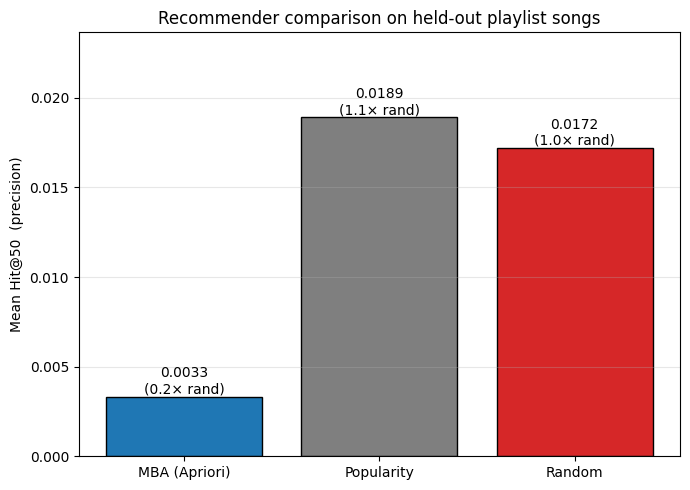

In [22]:
#now we can plot all the methods
#plot 1: MBA vs random
methods = ["MBA (Apriori)", "Popularity", "Random"]
values  = [mba_mean[50], pop_mean[50], rand_mean[50]]
colors  = ["#1f77b4", "#7f7f7f", "#d62728"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(methods, values, color=colors, edgecolor="black")

#annotate each bar with raw value + lift over random
baseline = rand_mean[50] if rand_mean[50] > 0 else 1e-12
for bar, v in zip(bars, values):
    lift = v / baseline
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{v:.4f}\n({lift:.1f}× rand)",
            ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Mean Hit@50  (precision)")
ax.set_title("Recommender comparison on held-out playlist songs")
ax.set_ylim(0, max(values) * 1.25)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

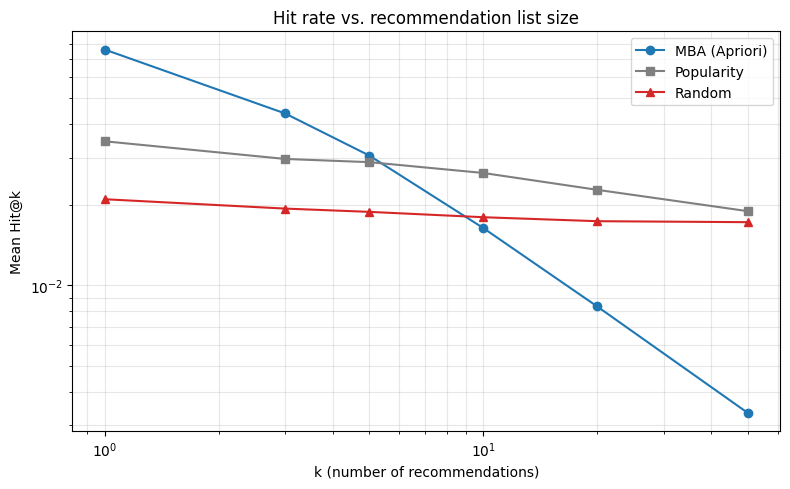

In [23]:
#plot 2: Hit rate vs reccomendation list based on k
ks = sorted(mba_mean.keys())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks, [mba_mean[k]  for k in ks], "o-", label="MBA (Apriori)", color="#1f77b4")
ax.plot(ks, [pop_mean[k]  for k in ks], "s-", label="Popularity",   color="#7f7f7f")
ax.plot(ks, [rand_mean[k] for k in ks], "^-", label="Random",       color="#d62728")

ax.set_xlabel("k (number of recommendations)")
ax.set_ylabel("Mean Hit@k")
ax.set_title("Hit rate vs. recommendation list size")
ax.set_xscale("log")
ax.set_yscale("log")          # comment out if random hits 0 at some k
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

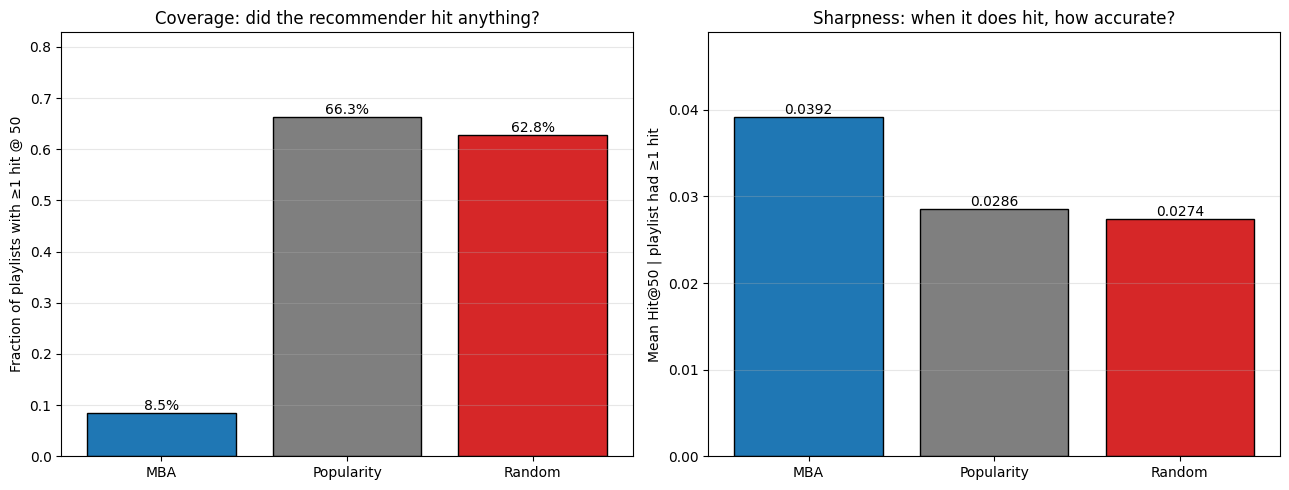

In [24]:
#plot 3: hit distr
def coverage(scores_at_50):
    #percentage of playlists that got a hit in recommendations
    return np.mean([s > 0 for s in scores_at_50])

cov = {
    "MBA":        coverage(mba_scores[50]),
    "Popularity": coverage(pop_scores[50]),
    "Random":     coverage(rand_scores[50]),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Coverage bar chart — % of playlists with any hit
axes[0].bar(cov.keys(), cov.values(),
            color=["#1f77b4", "#7f7f7f", "#d62728"], edgecolor="black")
for i, (name, v) in enumerate(cov.items()):
    axes[0].text(i, v, f"{v*100:.1f}%", ha="center", va="bottom")
axes[0].set_ylabel("Fraction of playlists with ≥1 hit @ 50")
axes[0].set_title("Coverage: did the recommender hit anything?")
axes[0].set_ylim(0, max(cov.values()) * 1.25)
axes[0].grid(axis="y", alpha=0.3)

#conditional precision when playlist receives a hit, how precise was the hit
def conditional_mean(scores):
    pos = [s for s in scores if s > 0]
    return np.mean(pos) if pos else 0

cond = {
    "MBA":        conditional_mean(mba_scores[50]),
    "Popularity": conditional_mean(pop_scores[50]),
    "Random":     conditional_mean(rand_scores[50]),
}
axes[1].bar(cond.keys(), cond.values(),
            color=["#1f77b4", "#7f7f7f", "#d62728"], edgecolor="black")
for i, (name, v) in enumerate(cond.items()):
    axes[1].text(i, v, f"{v:.4f}", ha="center", va="bottom")
axes[1].set_ylabel("Mean Hit@50 | playlist had ≥1 hit")
axes[1].set_title("Sharpness: when it does hit, how accurate?")
axes[1].set_ylim(0, max(cond.values()) * 1.25)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()